# Projeto de Detecção de Fraudes em Crédito (DIO - Bradesco)

In [1]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

## Feature Engineering

In [3]:
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"]) #log1p é para previnir log(0)

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.86      0.67      0.75       148

    accuracy                           1.00     85443
   macro avg       0.93      0.83      0.88     85443
weighted avg       1.00      1.00      1.00     85443



Recall de 0,67, modelo só identifica 67% das fraudes reais. 

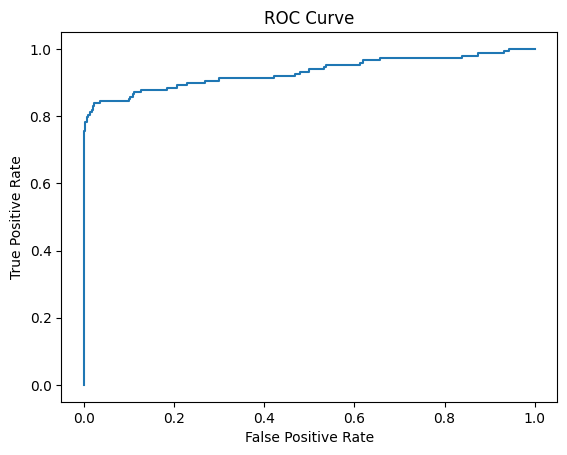

AUC: 0.9301709646806076


In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt 

y_probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

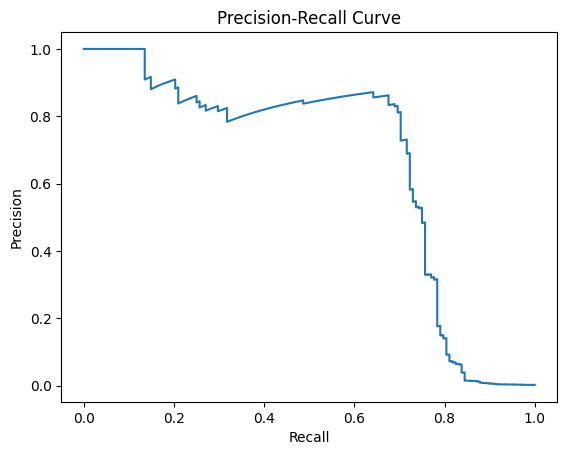

In [9]:
from sklearn.metrics import precision_recall_curve


precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

## Balanceamento de Dados

In [10]:
fraudes = df[df["Class"] == 1]

normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X,y)

In [90]:
from sklearn.ensemble import RandomForestClassifier

rf_aula = RandomForestClassifier(
    n_estimators = 50,
    max_depth = 10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf_aula.fit(X_train, y_train)

y_pred_rf = rf_aula.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.80       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [92]:
print('roc_auc:', roc_auc_score(y_test, y_pred_rf))
print('aucprc:', average_precision_score(y_test, y_pred_rf))

roc_auc: 0.8816277925736277
aucprc: 0.6394987189007764


In [ ]:
from sklearn.pipeline import Pipeline 

pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred_aula = pipeline.predict(X_test)

In [ ]:
threshold = 0.3

y_pred_aula = (y_probs >threshold).astype(int)

print(classification_report(y_test, y_pred_aula))

print('roc_auc:', roc_auc_score(y_test, scores))
print('aucprc:' average_precision_score(y_test, scores))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.81      0.70      0.75       148

    accuracy                           1.00     85443
   macro avg       0.91      0.85      0.88     85443
weighted avg       1.00      1.00      1.00     85443



## Modelos XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight = 10,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/xgboost/training.py:200: UserWarning: [17:22:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



## Importância das variáveis

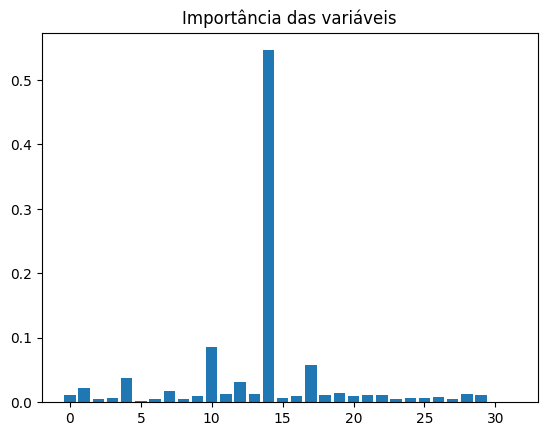

In [ ]:
importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

## Ajuste de hiperparâmetros

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric ="logloss"),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(X_train, y_train)

print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 5, 'n_estimators': 100}


## Explicabilidade (SHAP)

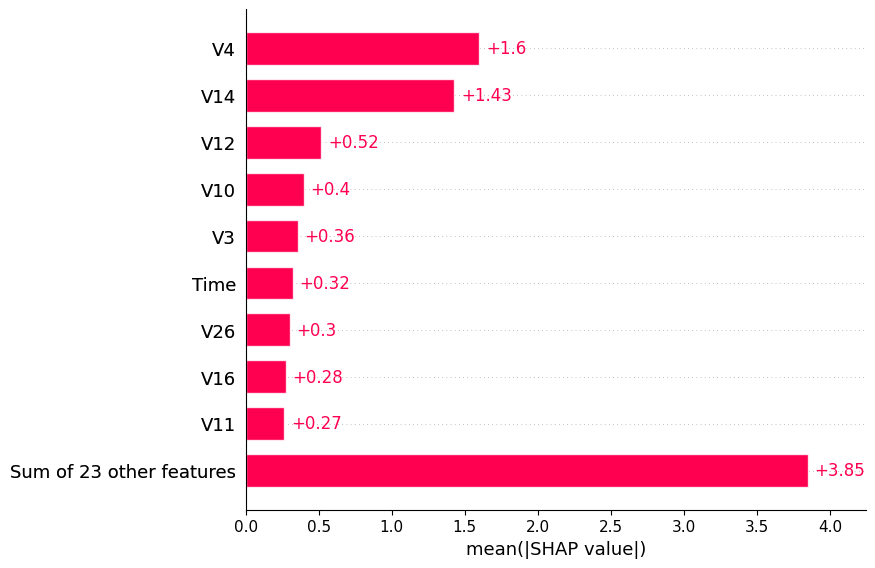

In [ ]:
import shap
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)

# Minha análise

In [ ]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, average_precision_score
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from pylab import rcParams
STATE = np.random.RandomState(42)


url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [93]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

## Análise Exploratória Inicial

In [104]:
fraudes = df[df['Class'] == 1]
valido = df[df['Class'] == 0]

outlier_fraction = len(fraudes) / len(valido)

print("Fraudes: {}".format(len(fraudes)))
print("Valido: {}".format(len(valido)))

Fraudes: 492
Valido: 284315


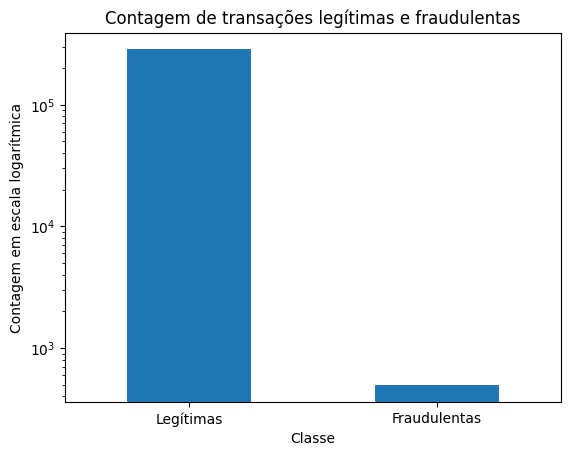

In [101]:
contagem = df['Class'].value_counts(sort=True)

contagem.plot(kind='bar', rot=0)

plt.title("Contagem de transações legítimas e fraudulentas")
plt.xlabel("Classe")
plt.ylabel("Contagem em escala logarítmica")
plt.yscale('log')  # Usar escala logarítmica para melhor visualização
plt.xticks(range(2), labels = ['Legítimas', 'Fraudulentas'])
plt.show()


In [102]:
fraudes.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [103]:
fraudes['Amount'].value_counts()

Amount
1.00      113
0.00       27
99.99      27
0.76       17
0.77       10
         ... 
349.08      1
390.00      1
77.89       1
245.00      1
42.53       1
Name: count, Length: 259, dtype: int64

Ou seja, a maior parte das transações fraudulentas nessa database é de valores baixos

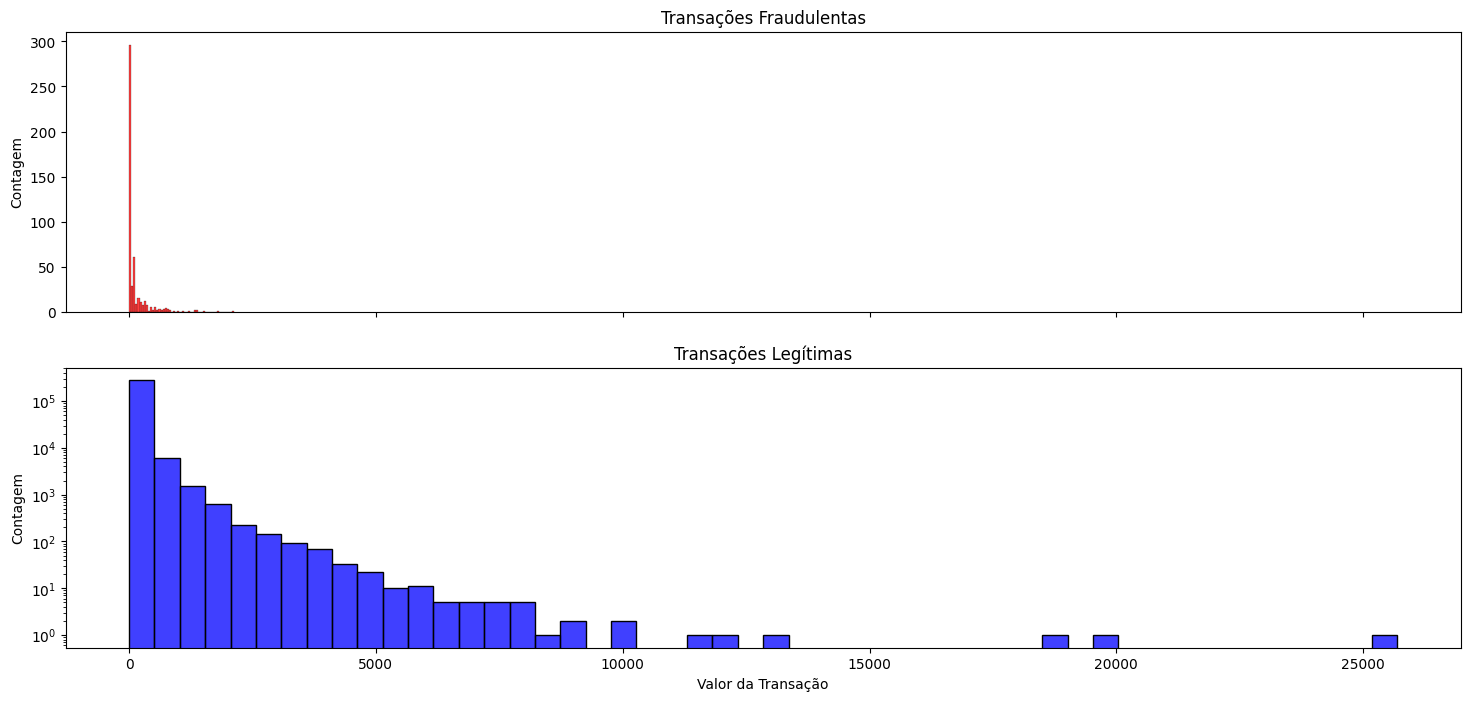

In [106]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.set_size_inches(18, 8)
sns.histplot(valido['Amount'], bins=50, ax=ax2, color='blue')
sns.histplot(fraudes['Amount'], bins=50, ax=ax1, color='red')
ax2.set_title('Transações Legítimas')
ax1.set_title('Transações Fraudulentas')
ax2.set_xlabel('Valor da Transação')
ax1.set_ylabel('Contagem')
ax2.set_ylabel('Contagem')
ax1.set_xlabel('Valor da Transação')
plt.yscale('log')  # Usar escala logarítmica para melhor visualização
plt.show()

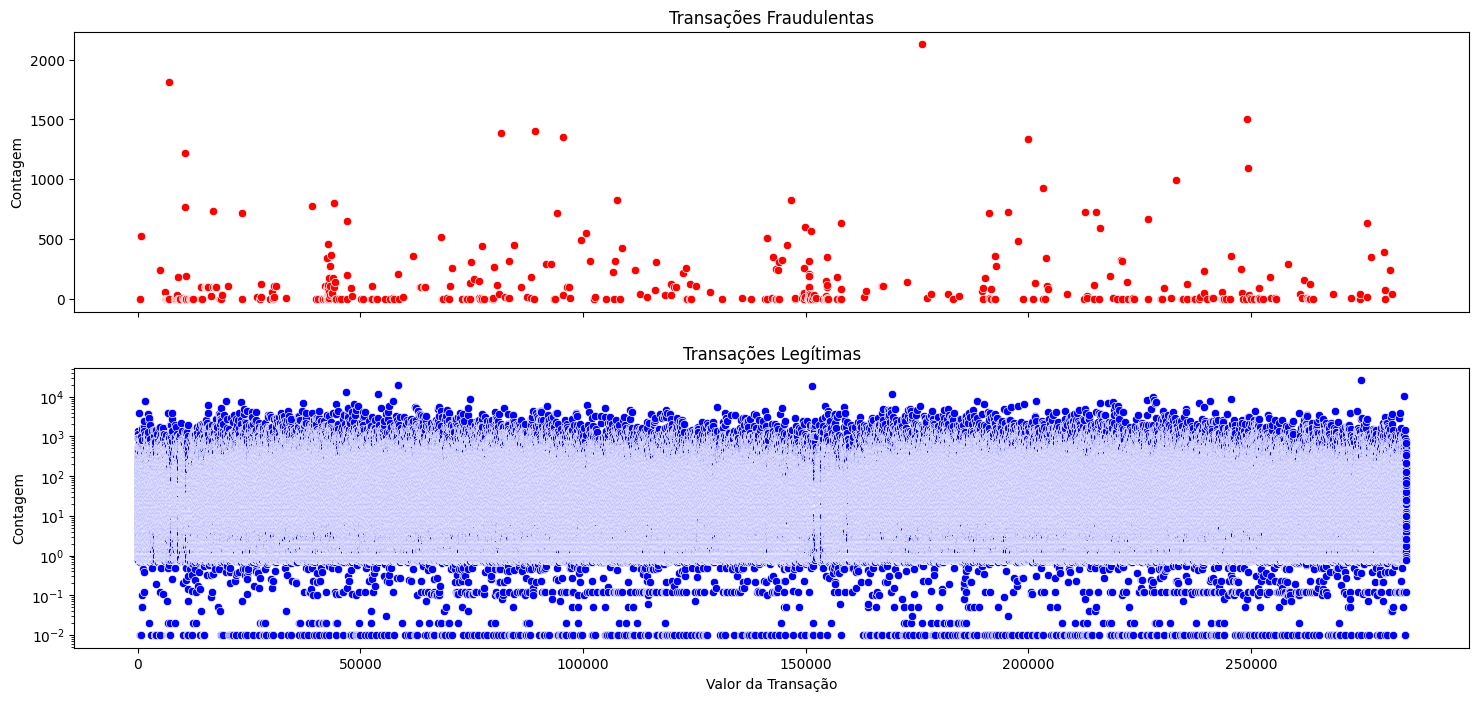

In [108]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.set_size_inches(18, 8)
sns.scatterplot(valido['Amount'], ax=ax2, color='blue')
sns.scatterplot(fraudes['Amount'], ax=ax1, color='red')
ax2.set_title('Transações Legítimas')
ax1.set_title('Transações Fraudulentas')
ax2.set_xlabel('Valor da Transação')
ax1.set_ylabel('Contagem')
ax2.set_ylabel('Contagem')
ax1.set_xlabel('Valor da Transação')
plt.yscale('log')  # Usar escala logarítmica para melhor visualização
plt.show()

/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


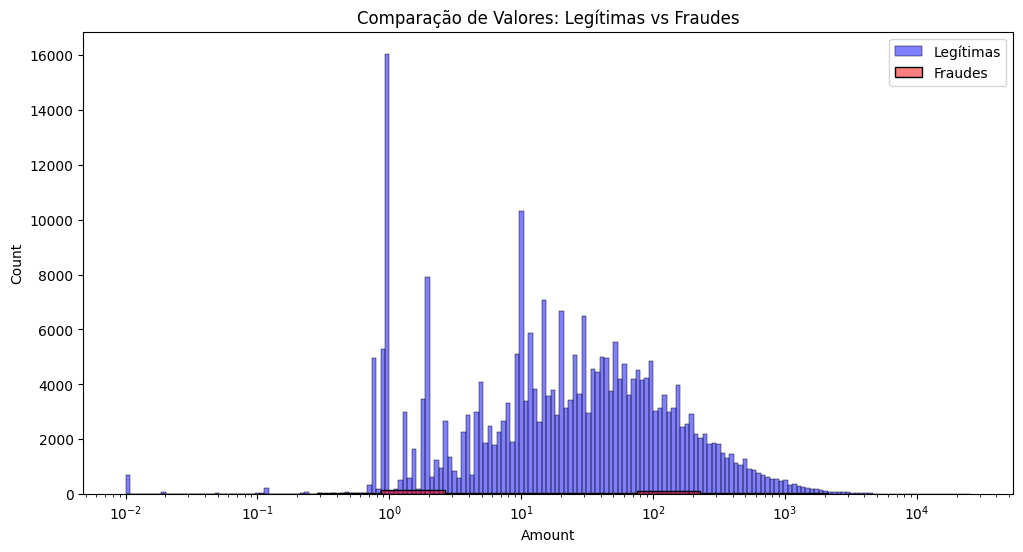

In [110]:
plt.figure(figsize=(12, 6))
sns.histplot(valido['Amount'], color='blue', label='Legítimas', kde=True, log_scale=True)
sns.histplot(fraudes['Amount'], color='red', label='Fraudes', kde=True, log_scale=True)
plt.title('Comparação de Valores: Legítimas vs Fraudes')
plt.legend()
plt.show()

/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


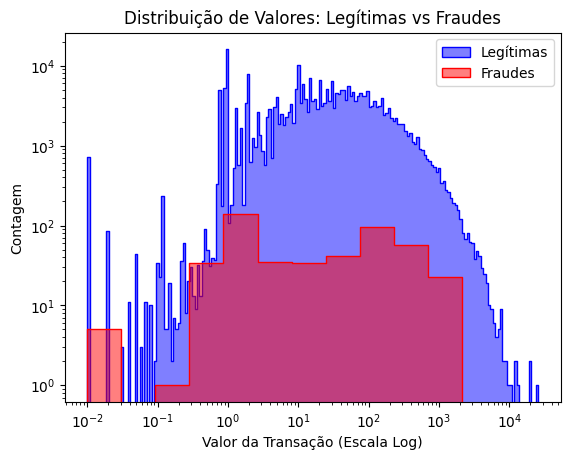

In [111]:
sns.histplot(data=valido, x='Amount', color='blue', label='Legítimas', kde=True, element='step', log_scale=True)
sns.histplot(data=fraudes, x='Amount', color='red', label='Fraudes', kde=True, element='step', log_scale=True)

plt.title('Distribuição de Valores: Legítimas vs Fraudes')
plt.xlabel('Valor da Transação (Escala Log)')
plt.ylabel('Contagem')
plt.legend()
plt.yscale('log')  # Usar escala logarítmica para melhor visualização
plt.show()

/tmp/ipykernel_16195/3159889417.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='Class', y='Amount', palette={'Legitima': 'b', 'Fraude': 'r'})


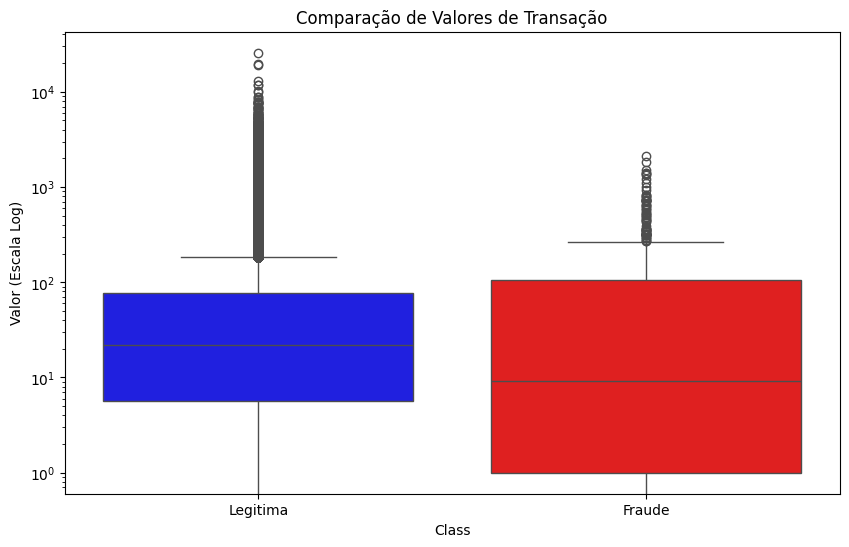

In [112]:
valido['Class'] = 'Legitima'
fraudes['Class'] = 'Fraude'
df_combined = pd.concat([valido, fraudes])


plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='Class', y='Amount', palette={'Legitima': 'b', 'Fraude': 'r'})

plt.yscale('log') # Useful if there are massive outliers
plt.title('Comparação de Valores de Transação')
plt.ylabel('Valor (Escala Log)')
plt.show()

## Modelos de predição e feature engineering

In [114]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42
)

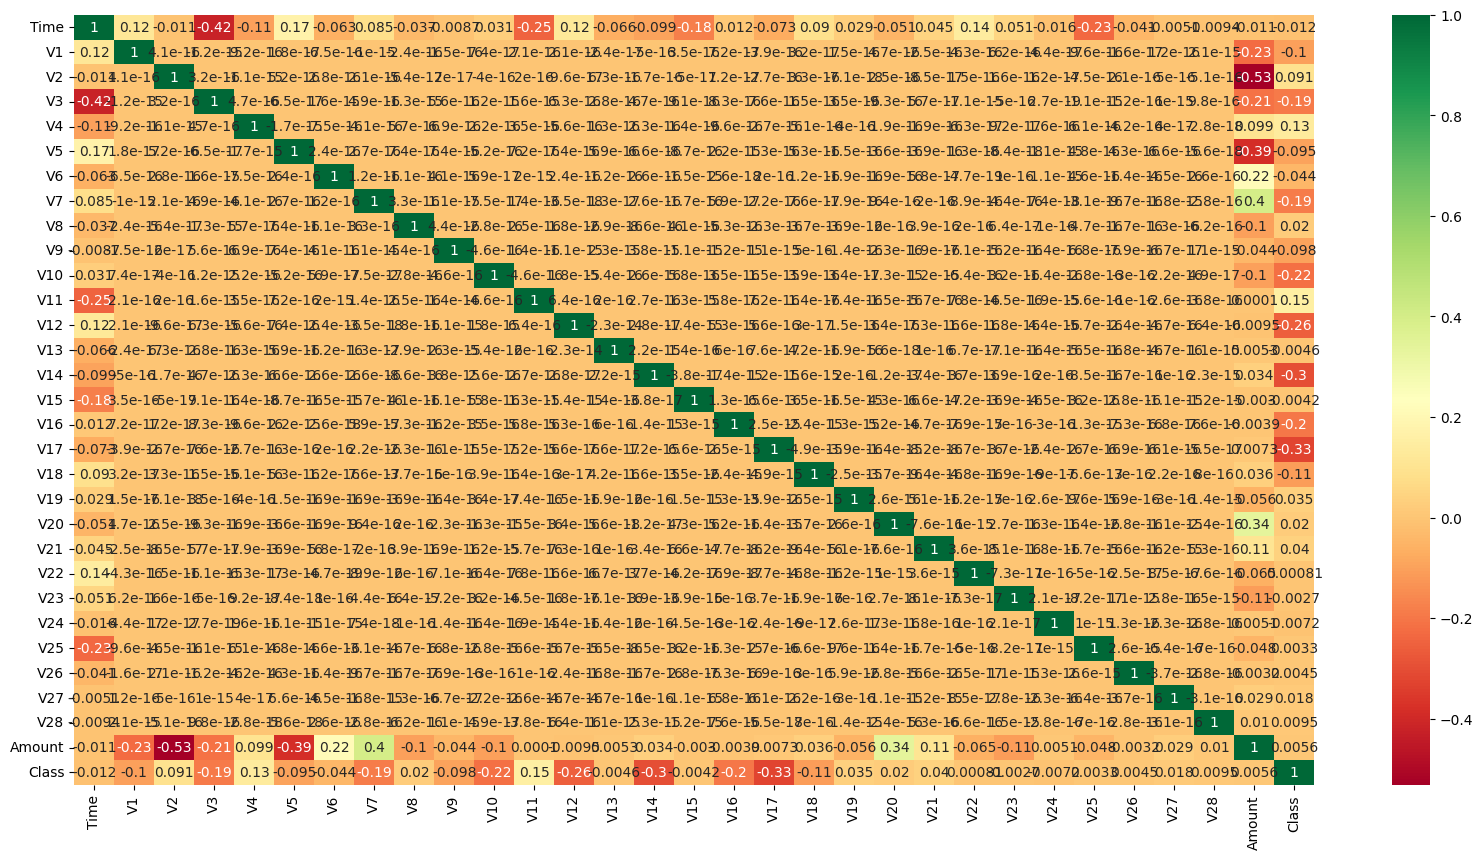

In [115]:
correlation_matriz = df.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,10))

g = sns.heatmap(df[top_corr_features].corr(), annot=True, cmap="RdYlGn")

In [116]:
models = { }

print("Treinando Logistic Regression...")
lr = LogisticRegression(max_iter=1000,
                        solver='lbfgs',
                        class_weight='balanced',
                        verbose=0
) 

lr.fit(X_train, y_train)
models['Logistic Regression'] = lr
print("Logistic Regression treinado.")

#Random Forest
print("Treinando Random Forest...")
rf = RandomForestClassifier(n_estimators=100,
                            max_depth=12,
                            min_samples_leaf=100,
                            class_weight='balanced',
                            n_jobs=-1,
                            random_state=STATE
)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
print("Random Forest treinado.")

print("Treinando Isolation Forest...")
isolation_forest = IsolationForest(n_estimators=100, 
                     max_samples=len(X),
                     contamination=outlier_fraction, 
                     random_state=42, 
                     verbose=0)
    
    
isolation_forest.fit(X_train, y_train)
models['Isolation Forest'] = isolation_forest

Treinando Logistic Regression...


/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression treinado.
Treinando Random Forest...
Random Forest treinado.
Treinando Isolation Forest...


/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/ensemble/_iforest.py:344: UserWarning: max_samples (284807) is greater than the total number of samples (199364). max_samples will be set to n_samples for estimation.
  warn(


In [117]:
results = []

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_test)[:, 1]
    else:
        scores = model.decision_function(X_test)
    print('\n', name)
    print(classification_report(y_test, (scores>0.8).astype(int)))
    results.append({
        'model': name,
        'roc_auc': roc_auc_score(y_test, scores),
        'aucprc': average_precision_score(y_test, scores)
    })

pd.DataFrame(results).sort_values(by='aucprc', ascending=False)


 Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     85295
           1       0.16      0.84      0.27       148

    accuracy                           0.99     85443
   macro avg       0.58      0.92      0.63     85443
weighted avg       1.00      0.99      0.99     85443


 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.81      0.74      0.77       148

    accuracy                           1.00     85443
   macro avg       0.90      0.87      0.89     85443
weighted avg       1.00      1.00      1.00     85443


 Isolation Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.00      0.00      0.00       148

    accuracy                           1.00     85443
   macro avg       0.50      0.50      0.50     85443
weighted avg     

/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/felipe/Estudos/VirtualEnv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

,model,roc_auc,aucprc
0,Logistic Regression,0.966032,0.697229
1,Random Forest,0.970570,0.665875
2,Isolation Forest,0.060266,0.000885


Uma piora é observada no logistic regression com relação ao da aula, provavelmente devido a falta de uma padronização de escala nas features no meu método, no entanto Random Forest possui uma performance melhor, portanto prefiro ele a melhorar Logistic. O método isolation forest é o pior de todos, daria o mesmo resultado que um teste dummy.

In [118]:
import joblib

joblib.dump(models["Random Forest"], 'random_forest_fraude.joblib')

['random_forest_fraude.joblib']